## Read in 12 months of daily mean T2m files and compute the 75th percentile temp for each cell to identify "summer" for that year as a test

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [14]:
file_path = '../../../Data/ERA5-global/*.nc'

# open without dask chunking and see if it crashes
#ds = xr.open_mfdataset(file_path) #, chunks={'time': 10})

# can't do quantile calc unless we are chunked
ds = xr.open_mfdataset(file_path, chunks={'latitude': 10, 'longitude': 10})

In [15]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 366, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1980-01-01 1980-01-02 ... 1980-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 2GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-05-23T10:38 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [16]:
ds.nbytes

1520003584

### one year is 1.5 GB!! <br>

### plot global mean temp across the year, weighted by latitude

In [17]:
# can weight these cells use cos(lat) because it is a regular grid
# need to look up or ask what this is saying - kinda get it but just to be sure!

weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights" # not sure why we did this since we aren't merging with the dataset but OK

# get weighted spatial mean
ds_t2m_ts = ds.weighted(weights).mean(["lon","lat"])
ds_t2m_ts                                             

<xarray.Dataset> Size: 6kB
Dimensions:      (time: 366)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1980-01-01 1980-01-02 ... 1980-12-31
    realization  int64 8B 0
Data variables:
    t2m          (time) float64 3kB dask.array<chunksize=(31,), meta=np.ndarray>

Text(0.5, 1.0, '')

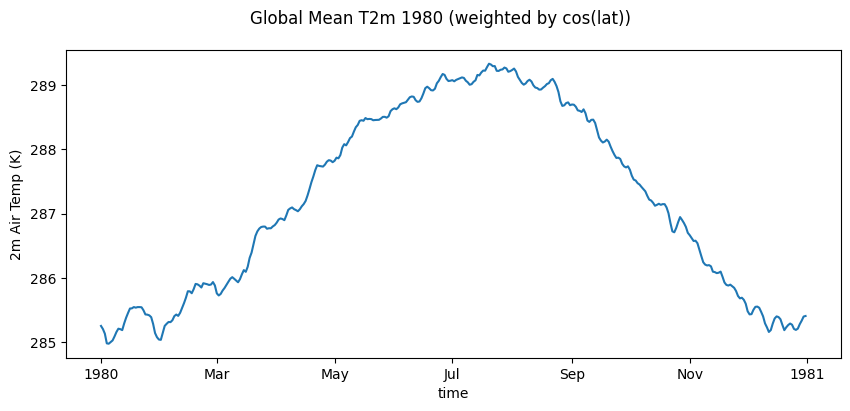

In [18]:
# plot the time series
fig,ax = plt.subplots(1,1, figsize=(10,4))
ds_t2m_ts.t2m.plot()
ax.set_ylabel("2m Air Temp (K)")
#ax.xaxis.set_tick_params(rotation=45)
plt.suptitle("Global Mean T2m 1980 (weighted by cos(lat))")
plt.title("")

In [21]:
ds.chunks

Frozen({'time': (31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31), 'lat': (721,), 'lon': (1440,)})

### compute 75th percentile values for each grid cell

In [26]:
# load it into memory because I can't do quantile on on the dask array, apparently
ds.load()

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 366, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1980-01-01 1980-01-02 ... 1980-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 2GB 244.4 244.4 244.4 ... 248.7 248.7
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-05-23T10:38 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

1520003584

In [29]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds.t2m.quantile(0.75, dim=('time'))
c_75

CPU times: user 27.4 s, sys: 9.07 ms, total: 27.4 s
Wall time: 27.6 s


<xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 8MB
array([[236.90471649, 236.90471649, 236.90471649, ..., 236.90471649,
        236.90471649, 236.90471649],
       [236.55875778, 236.55904007, 236.5591011 , ..., 236.55800247,
        236.55845642, 236.55863571],
       [236.50688934, 236.50760269, 236.50787354, ..., 236.5053215 ,
        236.50579071, 236.50622559],
       ...,
       [269.8968277 , 269.8964386 , 269.89590454, ..., 269.8978653 ,
        269.89752197, 269.89718628],
       [269.9214859 , 269.92115021, 269.9212265 , ..., 269.92185211,
        269.92188263, 269.92153931],
       [270.1100235 , 270.1100235 , 270.1100235 , ..., 270.1100235 ,
        270.1100235 , 270.1100235 ]])
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B 0.75

### plot one grid cell's time series and when it is above 75th percentile for the year, a.k.a. "summer"

Text(0, 0.5, 'Daily Temp (K)')

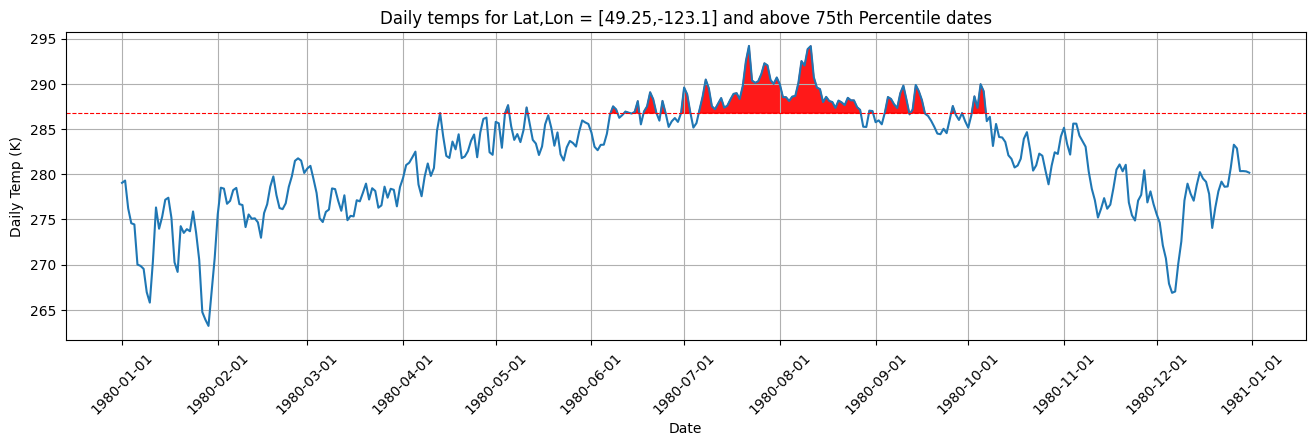

In [49]:
# plot for upper left cell the daily max temps and the 90th percentile
plot_data = ds.t2m.sel(lat=49.25,lon=-123.1, method="nearest") # Vancouver 49.246292, -123.116226
plot_c_75 = c_75.sel(lat=49.25,lon=-123.1, method="nearest")
plt.figure(figsize=(16,4))
plt.plot(plot_data.time, plot_data.data)
plt.fill_between(  # plot with color in between
    plot_data.time,  # x values
    # top boundary - y values above 0.5
    plot_data.data,
    plot_c_75,  # bottom boundary - 0.5
    where=(plot_data >= plot_c_75),
    color="red",  # color
    alpha=0.9,  # transparency value
    interpolate=True
)
plt.axhline(plot_c_75, color="red", linewidth=0.8, linestyle="dashed")
plt.tick_params(axis='x',rotation=45)
plt.xticks(["1980-01","1980-02","1980-03","1980-04","1980-05","1980-06",
           "1980-07","1980-08","1980-09","1980-10","1980-11","1980-12","1981-01"])
plt.grid()
#plt.ylim([280,315])
plt.title("Daily temps for Lat,Lon = [49.25,-123.1] and above 75th Percentile dates")
plt.xlabel("Date")
plt.ylabel("Daily Temp (K)")


### to-do
- fit polynomial? use harmonic? Use 5 consecutive days?
- find intersections
- get duration in days - use where() to get those above threshold and then count days